https://github.com/NASA-IMPACT/hls-foundation-os/blob/main/exploration.ipynb

In [43]:
!uv pip install contextily

Resolved 30 packages in 838ms                                                
Downloaded 5 packages in 409ms.1                                    
Installed 5 packages in 18ms2025.1.0                                
 + contextily==1.6.2
 + geographiclib==2.0
 + geopy==2.4.1
 + mercantile==1.2.1
 + xyzservices==2025.1.0


In [1]:
!apt-get update && apt-get install git-lfs -y
!git lfs install
!cd "data/" && git clone "https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M" && cd -

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]     
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [53.3 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [3799 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1531 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2941 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1319 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports/universe amd64 Packages [35.2 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports/main amd6

In [2]:
!uv pip install -r "data/Prithvi-EO-2.0-300M/requirements.txt"

Resolved 46 packages in 1.04s                                                
Downloaded 4 packages in 303ms==0.29.1                              
Installed 4 packages in 6ms                                         
 + einops==0.8.1
 + huggingface-hub==0.29.1
 + safetensors==0.5.3
 + timm==1.0.15


In [1]:
import sys
sys.path.append("data/Prithvi-EO-2.0-300M/")

In [2]:
import os
from os.path import join
from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import json
from tqdm.auto import tqdm

from prithvi_mae import PrithviMAE

NO_DATA = -9999
NO_DATA_FLOAT = 0.0001
PERCENTILES = (0.1, 99.9)
DEVICE = "cuda"

In [3]:
root = Path("data/Prithvi-EO-2.0-300M/")

In [4]:
# load weights
weights_path = root / "Prithvi_EO_V2_300M.pt"
checkpoint = torch.load(weights_path, map_location="cpu")

# read model config
model_cfg_path = root / "config.json"
with open(model_cfg_path) as f:
    model_config = json.load(f)

# let us use only 1 frame for now (the model was trained on 3 frames)
model_config["num_frames"] = 1

# instantiate model
model = PrithviMAE(**model_config["pretrained_cfg"])
model.eval()

# load weights into model
# strict=false since we are loading with only 1 frame, but the warning is expected
del checkpoint['encoder.pos_embed']
del checkpoint['decoder.decoder_pos_embed']

model.load_state_dict(checkpoint, strict=False)
model = model.to(DEVICE)

/tmp/ipykernel_2394/492960533.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location="cpu")


In [5]:
# statistics used to normalize images before passing to the model
means = np.array(model_config["pretrained_cfg"]["mean"]).squeeze()
stds = np.array(model_config["pretrained_cfg"]["std"]).squeeze()

# def preprocess_image(image):
#     # normalize image
#     C, H, W = image.shape
#     normalized = image.copy()
#     normalized = ((image - means) / stds)
#     normalized = normalized.reshape(1, C, 1, H, W)
#     normalized = torch.from_numpy(normalized).to(torch.float32)
#     return normalized

In [38]:
def features_to_embedding(features: list["torch.Tensor"]) -> "torch.Tensor":
    # index 0 is CLS token
    return features[-1][:, 0, :].squeeze()

---

In [7]:
import os

In [8]:
os.environ["GDAL_HTTP_NETRC_FILE"] = "/root/.netrc"
os.environ["CPL_DEBUG"] = "OFF"
os.environ["GDAL_NETRC"] = "YES"  # Forces GDAL to use ~/.netrc
os.environ["GDAL_HTTP_COOKIEFILE"] = "/tmp/cookies.txt"
os.environ["GDAL_HTTP_COOKIEJAR"] = "/tmp/cookies.txt"

In [9]:
import pystac_client
from rastervision.core.box import Box
from rastervision.core.data import (RasterioCRSTransformer, StatsTransformer,
                                    XarraySource)
from rastervision.core.data.raster_source import XarraySource
from shapely.geometry import mapping

/opt/conda/lib/python3.11/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.4 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [10]:
import rasterio as rio

In [11]:
import albumentations as A
import pandas as pd
import geopandas as gpd

In [12]:
import contextily as cx
from matplotlib import pyplot as plt
from matplotlib import patches
import geopandas as gpd

In [13]:
BANDS = [
    'B02', # blue
    'B03', # green
    'B04', # red
    'B05', # rededge1
    'B06', # rededge2
    'B07', # rededge3
]

In [14]:
bbox = Box(ymin=27.882688, xmin=67.577735, ymax=27.928327, xmax=67.627949)
bbox_geometry = mapping(bbox.to_shapely().oriented_envelope)
bbox

Box(ymin=27.882688, xmin=67.577735, ymax=27.928327, xmax=67.627949)

In [15]:
%%time
URL = 'https://cmr.earthdata.nasa.gov/stac/LPCLOUD/'
catalog = pystac_client.Client.open(URL)

items = catalog.search(
    intersects=bbox_geometry,
    collections=['HLSL30_2.0', 'HLSS30_2.0'],
    datetime='2012-01-01/2025-12-31',
    query={'eo:cloud_cover': {'lt': 5}},
).item_collection()
len(items)

CPU times: user 312 ms, sys: 27.2 ms, total: 339 ms
Wall time: 37.3 s


682

In [16]:
item_df = gpd.GeoDataFrame.from_features(items, crs="EPSG:4326")
print("#items original", len(item_df))
item_df = item_df[item_df.contains(bbox.to_shapely())]
print("#items that fully contain bbox", len(item_df))
# item_df['datetime'] = pd.to_datetime(item_df.loc[:, 'datetime'])
# item_df['date'] = item_df['datetime'].dt.date
# item_df = item_df.drop_duplicates(subset='date', keep='first')
# print("#items after date deduplication", len(item_df))

#items original 682
#items that fully contain bbox 682


In [ ]:
# URL = 'https://earth-search.aws.element84.com/v1'
# catalog = pystac_client.Client.open(URL)

# items_s2 = catalog.search(
#     intersects=bbox_geometry,
#     collections=['sentinel-2-c1-l2a'],
#     datetime='2025-01-01/2025-01-31',
#     query={'eo:cloud_cover': {'lt': 5}},
# ).item_collection()
# len(items_s2)

In [56]:
# raster_source_s2 = XarraySource.from_stac(
#     items_s2,
#     temporal=True,
#     allow_streaming=True,
#     stackstac_args=dict(assets=["red"], rescale=False, fill_value=0),
# )
# window = Box(ymin=1000, xmin=6000, ymax=1500, xmax=6500)
# raster_source_s2.crs_transformer.pixel_to_map(window, bbox=raster_source_s2.bbox)

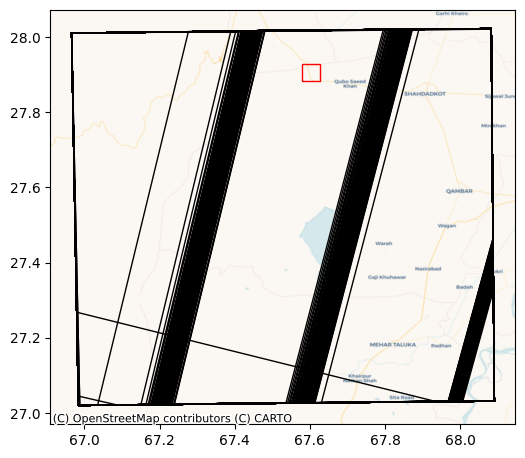

In [17]:
plt.close('all')
fig, ax = plt.subplots(figsize=(6, 6))

# plot bbox
xy_coords = bbox.to_points()
bbox_patch = patches.Polygon(xy_coords, color='red', fill=False)
ax.add_patch(bbox_patch)

gpd.GeoDataFrame.from_features(items).plot(ax=ax, ec='k', fc='none')
# gpd.GeoDataFrame.from_features(items_s2).plot(ax=ax, ec='g', fc='none')

cx.add_basemap(ax, crs='epsg:4326', source=cx.providers.CartoDB.Voyager)

plt.show()

In [18]:
raster_source = XarraySource.from_stac(
    items,
    bbox_map_coords=tuple(bbox),
    temporal=True,
    stackstac_args=dict(
        rescale=False, 
        fill_value=0, 
        assets=BANDS, 
        epsg=32642,
        resolution=30,
    ),
    allow_streaming=True,
)
raster_source.shape, raster_source.dtype

((682, 167, 167, 6), dtype('float64'))

In [63]:
stats_tf_viz = StatsTransformer(means=means[[2, 1, 0]], stds=stds[[2, 1, 0]])
raster_source_viz = XarraySource(
    raster_source.data_array,
    channel_order=[2, 1, 0],  # RGB
    crs_transformer=raster_source.crs_transformer,
    raster_transformers=[stats_tf_viz],
    bbox=raster_source.bbox,
    temporal=True,
)
raster_source_viz.shape

(10, 167, 167, 3)

  0%|          | 0/10 [00:00<?, ?it/s]

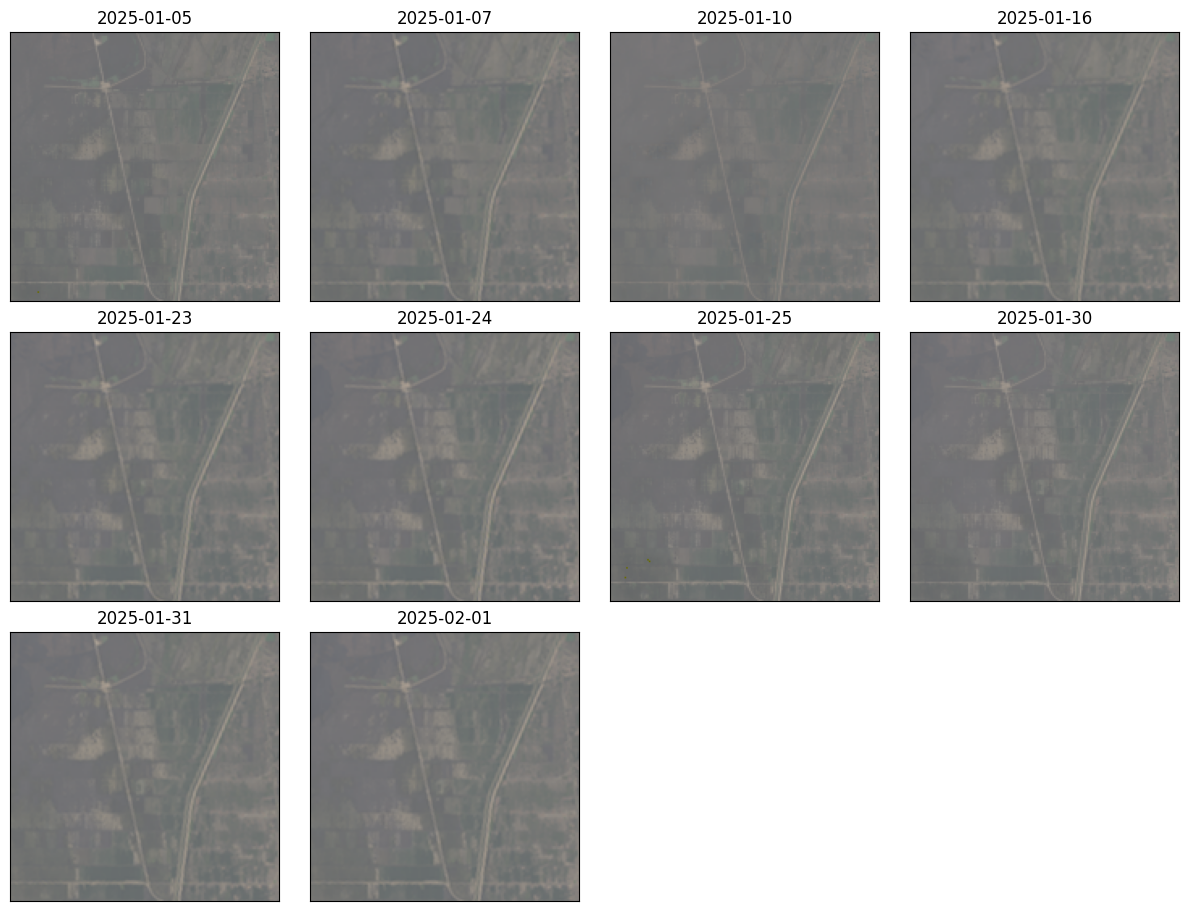

In [66]:
T = raster_source_viz.shape[0]
dates = [str(s.date()) for s in raster_source_viz.data_array.time.to_series()]

ncols = 4
nrows = int(np.ceil(T / ncols))
fig, axs = plt.subplots(
    nrows, ncols, figsize=(ncols * 3, nrows * 3), constrained_layout=True)
with tqdm(zip(range(T), dates, axs.flat), total=T) as bar:
    for t, date, ax in bar:
        chip = raster_source_viz[t, :, :]
        ax.imshow(chip)
        ax.set_title(date, fontsize=12)
        ax.tick_params(top=False, bottom=False, left=False, right=False,
                    labelleft=False, labelbottom=False, labeltop=False)
for ax in axs.flat[T:]:
    ax.axis('off')
plt.show()

In [9]:
# for k, asset in items[0].assets.items():
#     if k not in ("B02", "B03", "B04", "B05", "B06", "B07"):
#         continue
#     with rio.open(asset.href) as ds:
#         print(k, ds.crs)

B06 EPSG:32642
B05 EPSG:32642
B04 EPSG:32642
B07 EPSG:32642
B03 EPSG:32642
B02 EPSG:32642


In [21]:
tf = A.Compose([
    A.Normalize(mean=means.tolist(), std=stds.tolist()),
    A.Resize(224, 224),
])

In [22]:
class ChipDataset:
    def __init__(self, raster_source, transform):
        self.raster_source = raster_source
        self.transform = transform
        
    def __getitem__(self, i):
        x = self.raster_source[i, ...]
        x = self.transform(image=x)["image"]
        x = x.transpose(2, 0, 1)
        return x, torch.nan

    def __len__(self):
        return raster_source.shape[0]

In [23]:
ds = ChipDataset(raster_source, tf)
dl = DataLoader(ds, batch_size=4, num_workers=0, shuffle=False, pin_memory=True)
len(ds), len(dl)

(682, 171)

In [39]:
emb_dims = 1024
embeddings = torch.zeros(len(ds), emb_dims)

i = 0
with torch.inference_mode(), tqdm(dl, desc='Creating embeddings') as bar:
    for x, _ in bar:
        x = x.unsqueeze(2).float()
        x = x.to(DEVICE)
        emb = features_to_embedding(model.forward_features(x))
        embeddings[i:i + len(x)] = emb.cpu()
        i += len(x)

Creating embeddings:   0%|          | 0/171 [00:00<?, ?it/s]

In [40]:
dates = np.array([str(t.date()) for t in raster_source.data_array.time.to_series()])
dates

array(['2013-05-14', '2013-05-23', '2013-05-30', '2013-06-08',
       '2013-06-15', '2013-06-24', '2013-07-01', '2013-07-10',
       '2013-08-18', '2013-08-27', '2013-09-03', '2013-09-12',
       '2013-09-19', '2013-09-28', '2013-10-05', '2013-10-14',
       '2013-10-21', '2013-10-30', '2013-11-06', '2013-11-15',
       '2013-12-01', '2013-12-08', '2014-01-02', '2014-01-09',
       '2014-01-18', '2014-02-10', '2014-02-19', '2014-04-08',
       '2014-04-15', '2014-04-24', '2014-05-26', '2014-06-02',
       '2014-06-11', '2014-06-18', '2014-07-04', '2014-07-13',
       '2014-07-20', '2014-08-14', '2014-08-21', '2014-08-30',
       '2014-09-06', '2014-09-15', '2014-09-22', '2014-10-01',
       '2014-10-08', '2014-10-17', '2014-10-24', '2014-11-18',
       '2014-11-25', '2014-12-04', '2014-12-11', '2015-01-12',
       '2015-01-28', '2015-02-13', '2015-04-02', '2015-04-11',
       '2015-04-18', '2015-04-27', '2015-05-04', '2015-05-13',
       '2015-05-29', '2015-06-05', '2015-07-16', '2015-

In [41]:
embeddings_info = dict(
    embeddings=embeddings, 
    dates=dates, 
)
torch.save(embeddings_info, 'data/embeddings_prithvi2.pt')

In [42]:
!ls data/embeddings_prithvi2.pt

data/embeddings_prithvi2.pt


In [43]:
mask = dates != "NaT"
embeddings = embeddings[mask]
dates = dates[mask]

In [28]:
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
sns.reset_defaults()

In [31]:
t_doy = np.array([datetime.strptime(date, '%Y-%m-%d').timetuple().tm_yday for date in dates])
t_foy = np.clip(t_doy / 365, 0, 1)

In [44]:
embeddings -= embeddings.mean(axis=0)

In [45]:
from sklearn.decomposition import PCA

pca = PCA(whiten=True)
pca.fit(embeddings)
pca_emb = pca.transform(embeddings)
pca_emb.shape

(681, 681)

In [46]:
from sklearn.linear_model import RANSACRegressor
from matplotlib.colors import Normalize

def t_to_feats(t):
    feat_1 = np.sin(t * np.pi * 2)
    feat_2 = np.cos(t * np.pi * 2)
    return np.stack([feat_1, feat_2], axis=1)

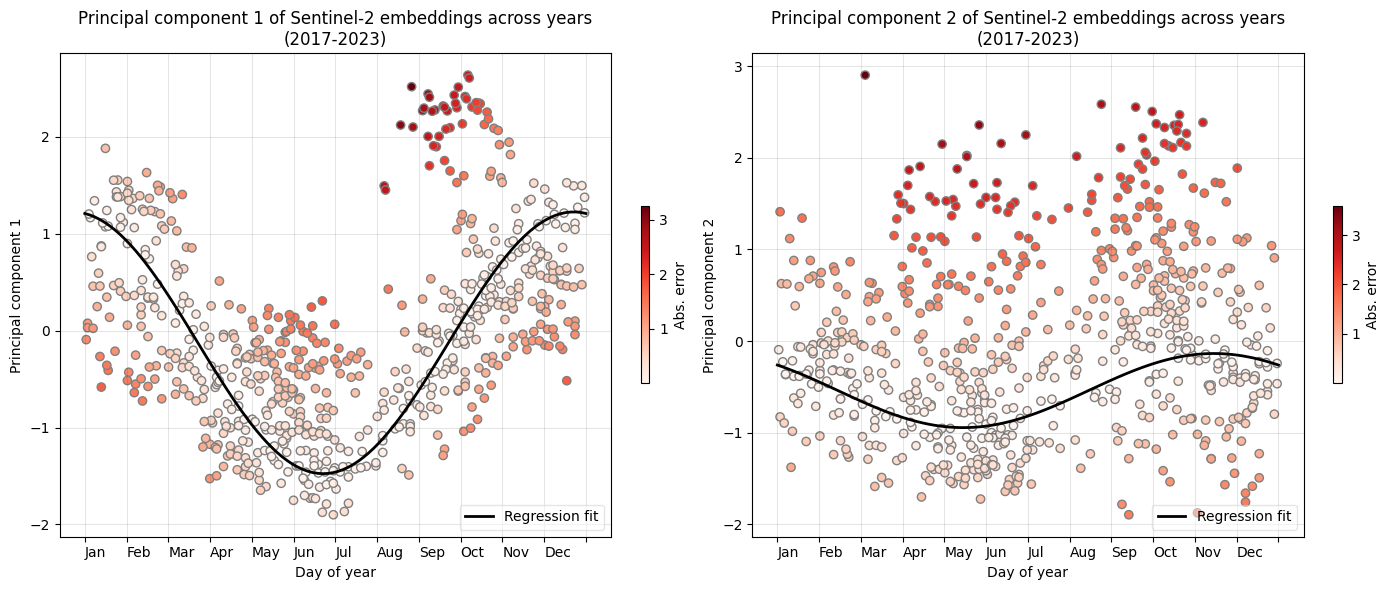

In [47]:
plt.close('all')
fig, axs = plt.subplots(1, 2, figsize=(14, 6), squeeze=True, tight_layout=True)
cmap = plt.get_cmap('Reds')

for pc, ax in enumerate(axs.flat):
    lr = RANSACRegressor()
    Y = pca_emb[:, pc]
    X = t_to_feats(t_foy)
    _ = lr.fit(X, Y)

    x = t_foy
    y_pred = lr.predict(t_to_feats(x))
    error = np.abs(y_pred - pca_emb[:, pc])
    norm = Normalize(error.min(), error.max())
    cols = cmap(norm(error))
    ax.scatter(x, pca_emb[:, pc], c=cols, ec='gray', alpha=1)

    t = np.linspace(0, 1, 100)
    x = t_to_feats(t)
    y_pred = lr.predict(x)
    ax.plot(t, y_pred, lw=2, c='k', label='Regression fit')
    ax.legend(loc='lower left')
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.015, label='Abs. error')
    
    ax.legend(loc='lower right', framealpha=0.5)
    ax.grid('--', c='k', alpha=0.1)
    ax.set_xticks(np.arange(0, 13) / 12, 
                  ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', ''])
    for tick in ax.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('left')
    ax.set_title(f'Principal component {pc + 1} of Sentinel-2 embeddings across years\n(2017-2023)')
    ax.set_xlabel('Day of year')
    ax.set_ylabel(f'Principal component {pc + 1}')

plt.show()

In [52]:
pc = 0
lr = RANSACRegressor()
Y = pca_emb[:, pc]
X = t_to_feats(t_foy)
_ = lr.fit(X, Y)

x = t_foy
y_pred = lr.predict(t_to_feats(x))
error = np.abs(y_pred - pca_emb[:, pc])

dates_flood = dates[(t_foy > 0.5) & (error > 2.)]
dates_flood

array(['2013-08-18', '2013-08-27', '2013-09-03', '2013-09-12',
       '2013-09-19', '2020-09-06', '2020-09-22', '2020-10-01',
       '2020-10-08', '2022-09-04', '2022-09-08', '2022-09-13',
       '2022-09-20', '2022-09-21', '2022-09-28', '2022-09-29',
       '2022-10-06', '2022-10-07', '2022-10-14', '2022-10-15',
       '2023-08-06', '2023-08-07', '2023-09-07', '2023-09-08',
       '2023-09-15', '2024-08-25', '2024-09-09', '2024-09-10',
       '2024-09-17', '2024-09-18', '2024-09-25', '2024-09-26',
       '2024-10-03', '2024-10-04', '2024-10-11', '2024-10-12'],
      dtype='<U10')

In [53]:
def to_t_day(date):
    timetuple = datetime.strptime(date, '%Y-%m-%d').timetuple()
    year = timetuple.tm_year
    doy = np.clip(timetuple.tm_yday / 365, 0, 1)
    return year + doy

t_doy_flood = np.array([datetime.strptime(date, '%Y-%m-%d').timetuple().tm_yday for date in dates_flood])
t_day = np.array([to_t_day(date) for date in dates])
t_day_flood = np.array([to_t_day(date) for date in dates_flood])

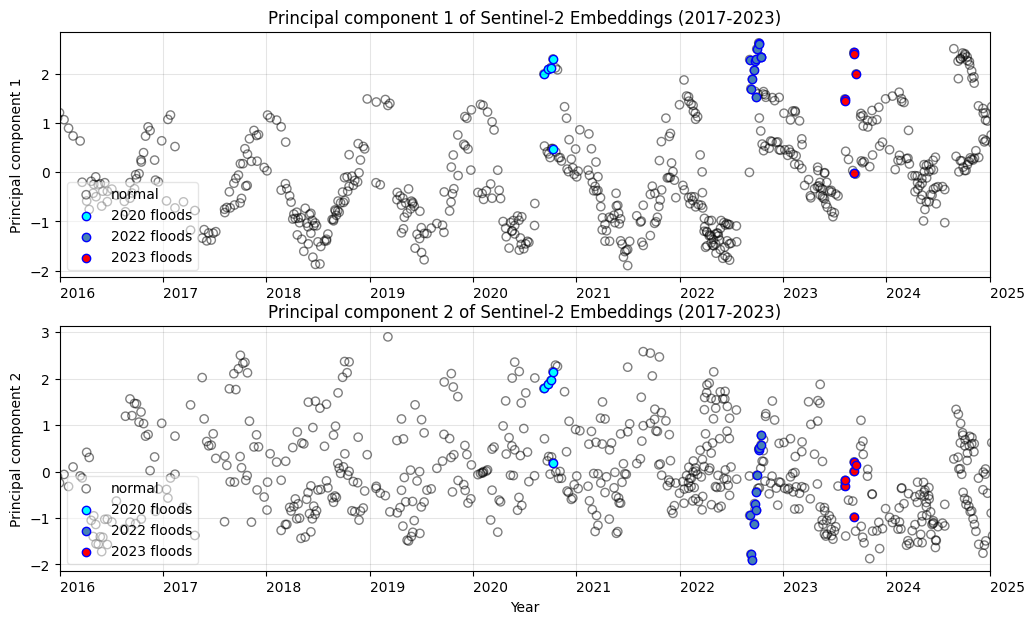

In [54]:
plt.close('all')
fig, axs = plt.subplots(2, 1, figsize=(12, 7), squeeze=True)

for pc, ax in enumerate(axs):
    ax.scatter(t_day, pca_emb[:, pc], ec='k', fc='none', alpha=0.5, label='normal')
    
    flood_dates_2020 = set([date for date in dates_flood if date.startswith('2020')])
    flood_inds_2020 = np.where([date in flood_dates_2020 for date in dates])[0]
    ax.scatter(t_day[flood_inds_2020], pca_emb[flood_inds_2020, pc], ec='b', fc='cyan', label='2020 floods')
    
    flood_dates_2022 = set([date for date in dates_flood if date.startswith('2022')])
    flood_inds_2022 = np.where([date in flood_dates_2022 for date in dates])[0]
    ax.scatter(t_day[flood_inds_2022], pca_emb[flood_inds_2022, pc], ec='b', fc='steelblue', label='2022 floods')
    
    flood_dates_2023 = set([date for date in dates_flood if date.startswith('2023')])
    flood_mask_2023 = np.array([date in flood_dates_2023 for date in dates])
    ax.scatter(t_day[flood_mask_2023], pca_emb[flood_mask_2023, pc], ec='b', fc='red', label='2023 floods')
    
    ax.legend(loc='lower left', framealpha=0.5)
    ax.grid('--', c='k', alpha=0.1)
    ax.set_title(f'Principal component {pc + 1} of Sentinel-2 Embeddings (2017-2023)')
    ax.set_xlim((2016, 2025))
    for tick in ax.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('left')
    ax.set_ylabel(f'Principal component {pc + 1}')
    if pc == len(axs) - 1:
        ax.set_xlabel('Year')

plt.show()